# Проект: классификация

## Какие данные нам предоставили, чтобы мы могли выявить решающие факторы для успеха маркетинговой кампании? В целом их можно разделить на несколько групп.  
### Данные о клиентах банка:  
age (возраст);  
job (сфера занятости);  
marital (семейное положение);  
education (уровень образования);  
default (имеется ли просроченный кредит);  
housing (имеется ли кредит на жильё);  
loan (имеется ли кредит на личные нужды);  
balance (баланс).  

### Данные, связанные с последним контактом в контексте текущей маркетинговой кампании:  
contact (тип контакта с клиентом);  
month (месяц, в котором был последний контакт);  
day (день, в который был последний контакт);  
duration (продолжительность контакта в секундах).  

### Прочие признаки:
campaign (количество контактов с этим клиентом в течение текущей кампании);  
pdays (количество пропущенных дней с момента последней маркетинговой кампании до контакта в текущей кампании);  
previous (количество контактов до текущей кампании)  
poutcome (результат прошлой маркетинговой кампании).  

И, разумеется, наша целевая переменная deposit, которая определяет, согласится ли клиент открыть депозит в банке. Именно её мы будем пытаться предсказать в данном кейсе.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from  sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing  import LabelEncoder
from sklearn import linear_model 
from sklearn import tree 
from sklearn import ensemble 
from sklearn import metrics 
from sklearn import preprocessing 
from sklearn.model_selection import train_test_split 
from sklearn.feature_selection import SelectKBest, f_classif

## Часть 1. Знакомство с данными, обработка пропусков и выбросов

### Задание 1

In [6]:
df = pd.read_csv('data/bank_fin.csv', sep = ';')

In [7]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,"2 343,00 $",yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,"45,00 $",no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,"1 270,00 $",yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,"2 476,00 $",yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,"184,00 $",no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [8]:
# исследуйте данные на предмет пропусков. Где есть пропущенные значения? Сколько их? 
# Для поиска пропусков вам понадобится метод info() или методы isnull() и sum().
df.isna().sum()

age           0
job           0
marital       0
education     0
default       0
balance      25
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
deposit       0
dtype: int64

### Задание 2

In [10]:
# есть ли в признаке job пропущенные значения? Возможно, они обозначены каким-то специальным словом?
print(df['job'].value_counts())

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64


### Задание 3

In [12]:
# преобразуйте признак balance таким образом, чтобы он корректно считывался, как вещественное число (float) 
# в данных содержится лишняя запятая и знак доллара
df['balance'] = df['balance'].apply(lambda x: (str(x).split('$')[0].replace(",", ".")))
df['balance'] = df['balance'].apply(lambda x: x.replace(" ", "")).astype(float)
print(df['balance'])

0        2343.0
1          45.0
2        1270.0
3        2476.0
4         184.0
          ...  
11157       1.0
11158     733.0
11159      29.0
11160       0.0
11161       0.0
Name: balance, Length: 11162, dtype: float64


In [13]:
# Вычислите среднее значение по преобразованному в корректный вид признаку balance. Ответ округлите до трёх знаков после точки-разделителя.
round(df['balance'].mean(), 3)

1529.129

### Задание 4

In [15]:
# обработайте пропуски в признаки balance , заменив их на медианные значения по данному признаку
df['balance'] = df['balance'].fillna(df['balance'].median())

In [16]:
#Вычислите среднее значение по преобразованному в корректный вид признаку balance. Ответ округлите до трёх знаков после точки-разделителя.
round(df['balance'].mean(), 3)

1526.936

### Задание 5

In [18]:
# Для начала выведем информацию по df
df.describe(include='all')

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
count,11162.000000,11162,11162,11162,11162,11162.000000,11162,11162,11162,11162.000000,11162,11162.000000,11162.000000,11162.000000,11162.000000,11162,11162
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,management,married,secondary,no,NaN,no,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,2566,6351,5476,10994,NaN,5881,9702,8042,NaN,2824,NaN,NaN,NaN,NaN,8326,5873
mean,41.231948,NaN,NaN,NaN,NaN,1526.936033,NaN,NaN,NaN,15.658036,NaN,371.993818,2.508421,51.330407,0.832557,NaN,NaN
std,11.913369,NaN,NaN,NaN,NaN,3224.829691,NaN,NaN,NaN,8.420740,NaN,347.128386,2.722077,108.758282,2.292007,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-6847.000000,NaN,NaN,NaN,1.000000,NaN,2.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,32.000000,NaN,NaN,NaN,NaN,123.000000,NaN,NaN,NaN,8.000000,NaN,138.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,550.000000,NaN,NaN,NaN,15.000000,NaN,255.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,49.000000,NaN,NaN,NaN,NaN,1699.000000,NaN,NaN,NaN,22.000000,NaN,496.000000,3.000000,20.750000,1.000000,NaN,NaN


In [19]:
# обработайте пропуски в категориальных признаках: job и education, заменив их на модальные значения
# Ранее мы выяснили, что в признаке job есть пропущенные значения, которые не отображаются как пропуски в явном виде.
df['job'] = df['job'].apply(lambda x: df['job'].mode()[0] if x=='unknown' else x)
print(df['job'].value_counts())
df['education'] = df['education'].apply(lambda x: df['education'].mode()[0] if x=='unknown' else x)
print(df['education'].value_counts())

job
management       2636
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
Name: count, dtype: int64
education
secondary    5973
tertiary     3689
primary      1500
Name: count, dtype: int64


In [20]:
# После замены пропусков рассчитайте средний баланс для клиентов с самой популярной работой и самым популярным уровнем образования 
#(т. е. для тех, у кого одновременно самая популярная работа и самое популярное образование). 
# Ответ округлите до трёх знаков после точки-разделителя.
mask = (df['job'] == 'management')&(df['education'] == 'secondary')
df.groupby(mask)['balance'].mean()


False    1524.427962
True     1598.882979
Name: balance, dtype: float64

### Задание 6

Изучите признак, отображающий баланс клиентов, на предмет выбросов.

В математической статистике есть несколько подходов, позволяющих определить наличие выбросов. Мы будем считать, что выбросы находятся за пределами отрезка, нижняя граница которого определяется как нижний квартиль, из которого вычли полтора межквартильных размаха () , а верхняя граница — как верхний квартиль, к которому прибавили полтора межквартильных размаха. (). Найдите эти границы, и отфильтруйте значения так, чтобы выбросов в данных не осталось.

In [23]:
# Вычисляем квантили вычисляются с помощью метода quantile(). 
# Потенциальные выбросы определяются при помощи фильтрации данных по условию выхода за пределы верхней или нижней границы.
def outliers_iqr_mod(data, feature, left=1.5, right=1.5):
    x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75),
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * left)
    upper_bound = quartile_3 + (iqr * right)
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

In [24]:
#Применим эту функцию к таблице и признаку balance, а также выведем размерности результатов:
outliers, cleaned = outliers_iqr_mod(df, 'balance')
print(f'Число выбросов по методу Тьюки: {outliers.shape[0]}')
print(f'Результирующее число записей: {cleaned.shape[0]}')


Число выбросов по методу Тьюки: 1057
Результирующее число записей: 10105


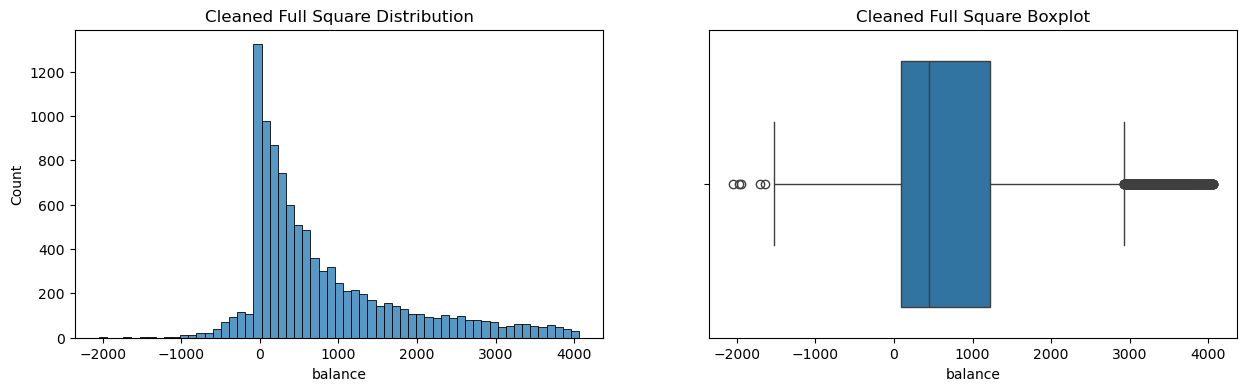

In [25]:
ig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
histplot = sns.histplot(data=cleaned, x='balance', ax=axes[0]);
histplot.set_title('Cleaned Full Square Distribution');
boxplot = sns.boxplot(data=cleaned, x='balance', ax=axes[1]);
boxplot.set_title('Cleaned Full Square Boxplot');

In [26]:
# Найду квартили, межквартильный размах, нижнюю и верхнюю границу выбросов
p25 = np.percentile(df['balance'], 25) #нижний квартиль
p75 = np.percentile(df['balance'], 75) #верхний квартиль
iqr = p75 - p25   #межквартильный размах

low = p25 - 1.5*iqr # нижняя граница
high = p75 + 1.5*iqr # верхняя граница
print(low, high)

-2241.0 4063.0


In [27]:
#  удалите все выбросы для признака balance. (Применю фильтрацию с пересечением двух условий)
data = df[(df['balance'] >= low) & (df['balance'] <= high)]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10105 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        10105 non-null  int64  
 1   job        10105 non-null  object 
 2   marital    10105 non-null  object 
 3   education  10105 non-null  object 
 4   default    10105 non-null  object 
 5   balance    10105 non-null  float64
 6   housing    10105 non-null  object 
 7   loan       10105 non-null  object 
 8   contact    10105 non-null  object 
 9   day        10105 non-null  int64  
 10  month      10105 non-null  object 
 11  duration   10105 non-null  int64  
 12  campaign   10105 non-null  int64  
 13  pdays      10105 non-null  int64  
 14  previous   10105 non-null  int64  
 15  poutcome   10105 non-null  object 
 16  deposit    10105 non-null  object 
dtypes: float64(1), int64(6), object(10)
memory usage: 1.4+ MB


## Часть 2:  Разведывательный анализ

### Задание 1

In [30]:
# изучите соотношение классов в ваших данных на предмет несбалансированности, проиллюстрируйте результат
# Давайте изучим распределение целевой переменной: есть ли несбалансированность классов? 
# Чтобы это определить, вычислите частоты для открывших депозит и для тех, кто его не открыл. 
# Сопроводите числа диаграммой, отражающей полученные результаты.
# Сколько клиентов открыли депозит?
print(data['deposit'].value_counts())

deposit
no     5424
yes    4681
Name: count, dtype: int64


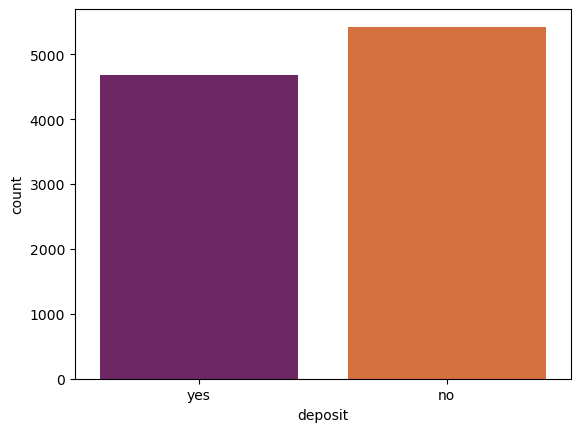

In [31]:
sns.countplot(x ='deposit', data = data, palette='inferno')

plt.show('png')

Классы относительно сбалансированны

### Задания 2 и 3

In [34]:
#рассчитайте описательные статистики для количественных переменных, проинтерпретируйте результат
# Каков максимальный возраст клиента банка?
data.describe()

,age,balance,day,duration,campaign,pdays,previous
count,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000,10105.000000
mean,40.895497,807.653538,15.590302,368.742603,2.517170,51.319644,0.816230
std,11.734931,994.151966,8.441510,346.651524,2.707159,109.644179,2.243795
min,18.000000,-2049.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,95.000000,8.000000,137.000000,1.000000,-1.000000,0.000000
50%,38.000000,445.000000,15.000000,252.000000,2.000000,-1.000000,0.000000
75%,48.000000,1227.000000,22.000000,490.000000,3.000000,2.000000,1.000000
max,95.000000,4063.000000,31.000000,3881.000000,43.000000,854.000000,58.000000


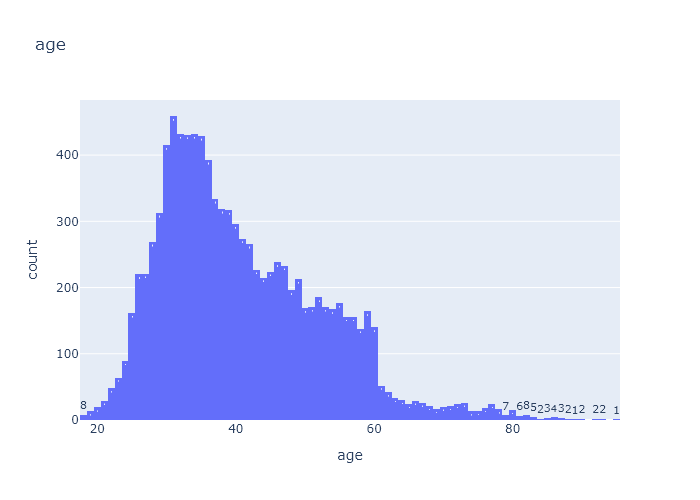

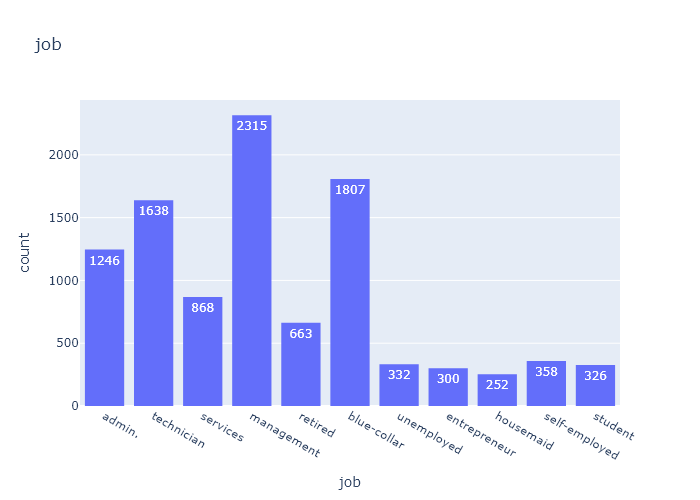

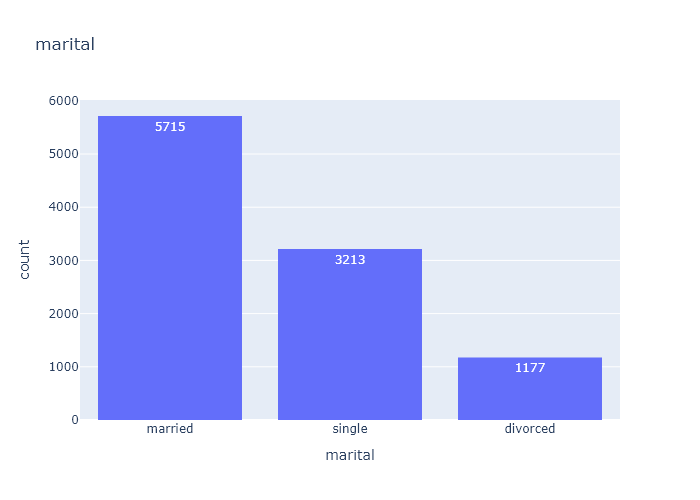

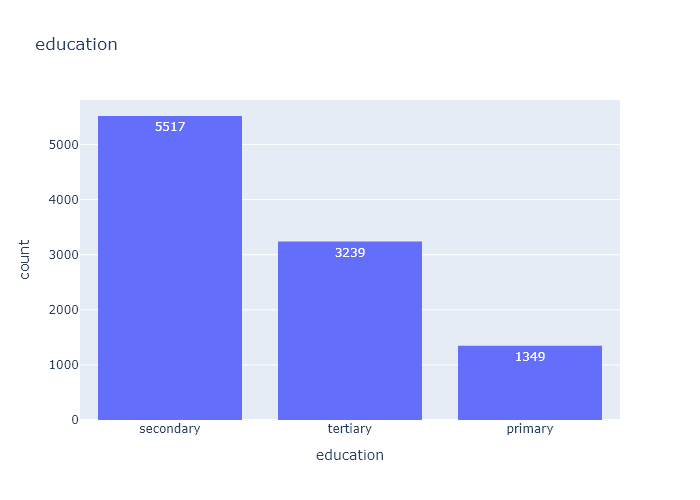

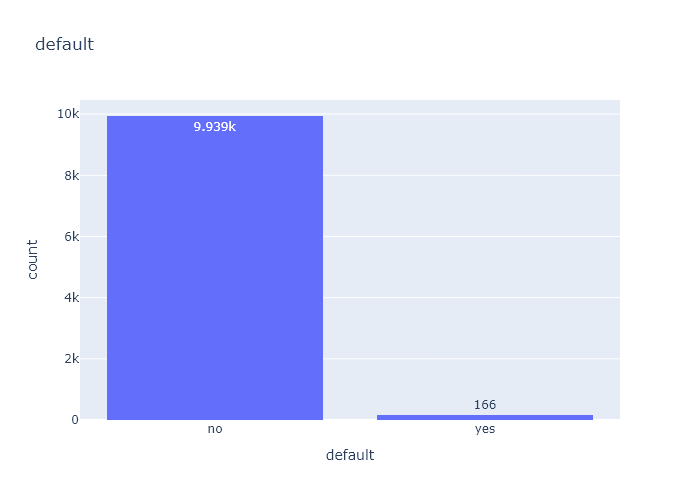

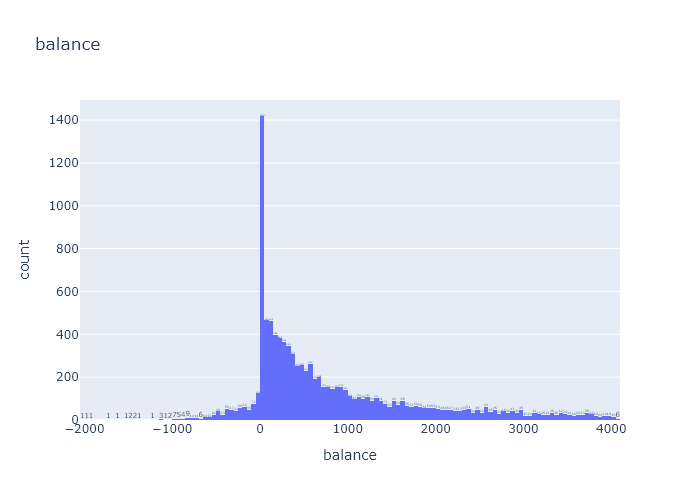

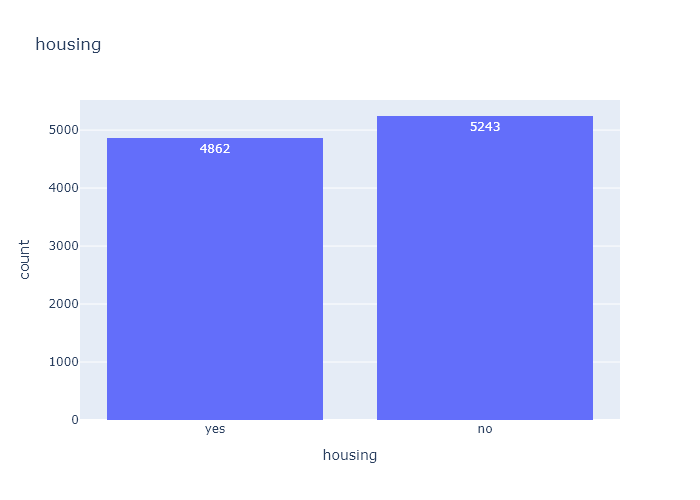

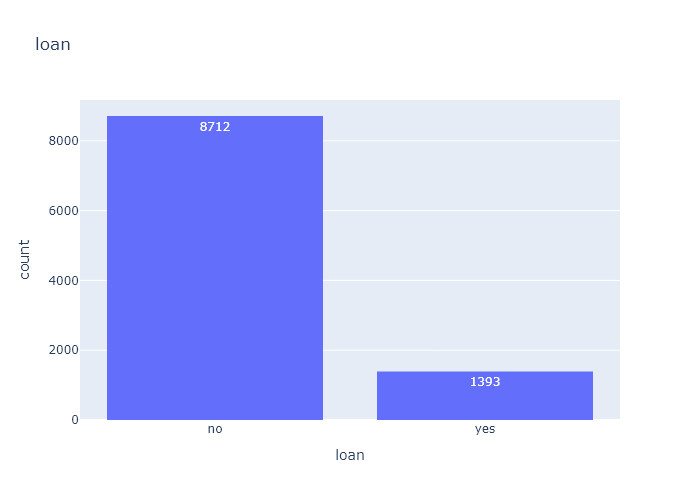

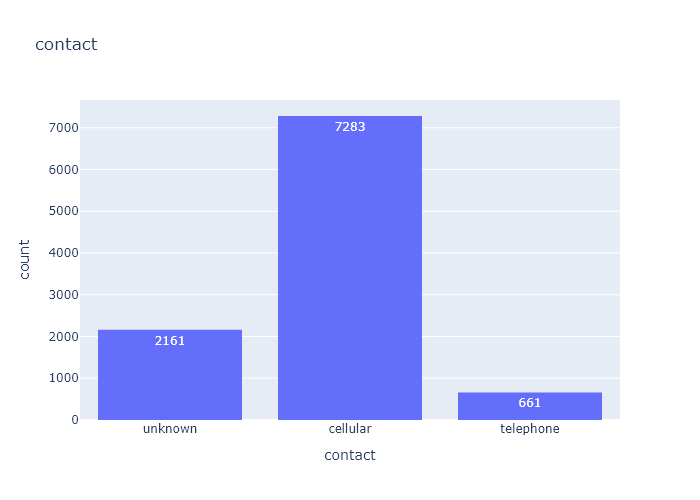

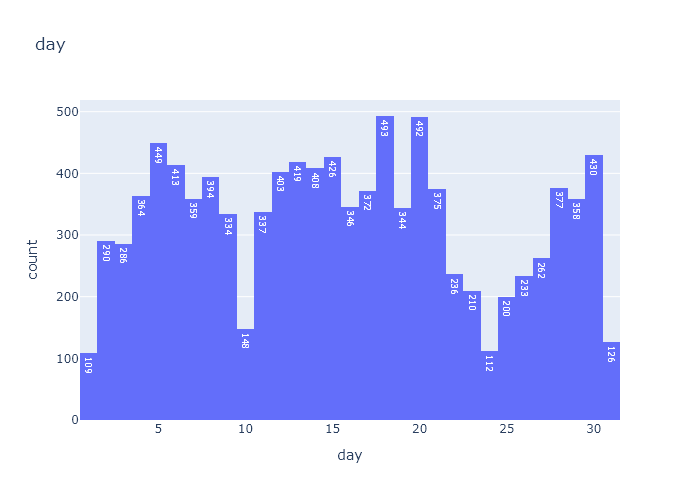

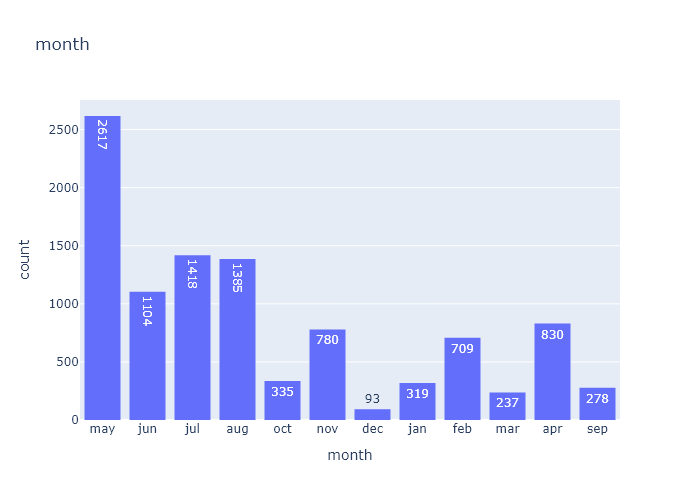

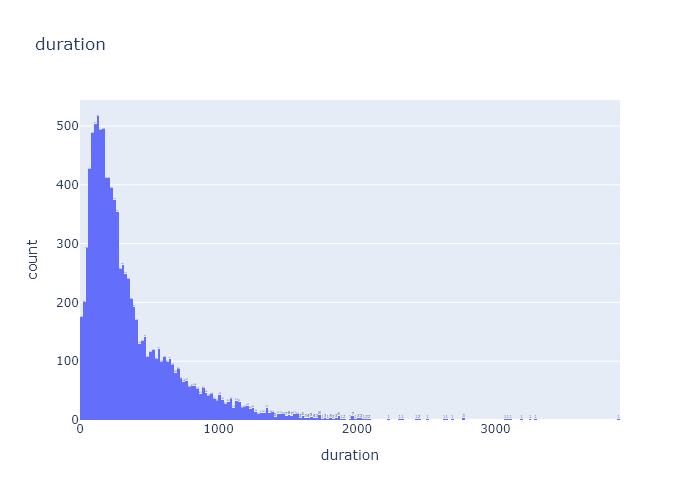

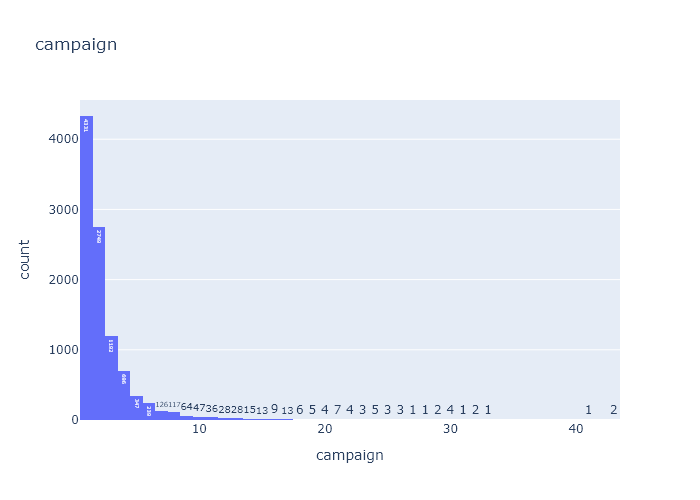

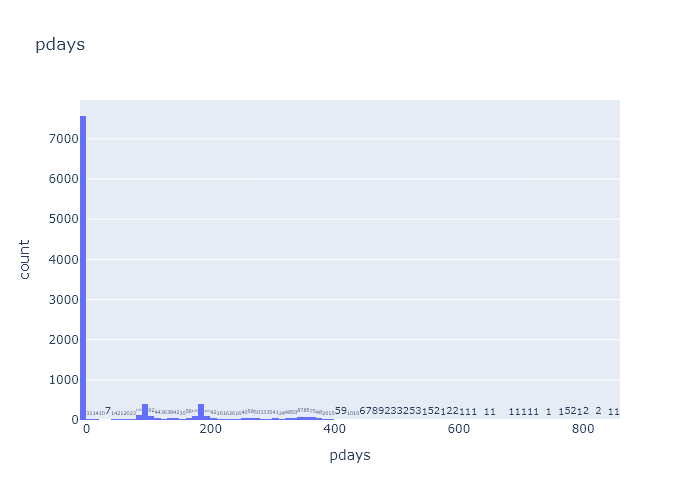

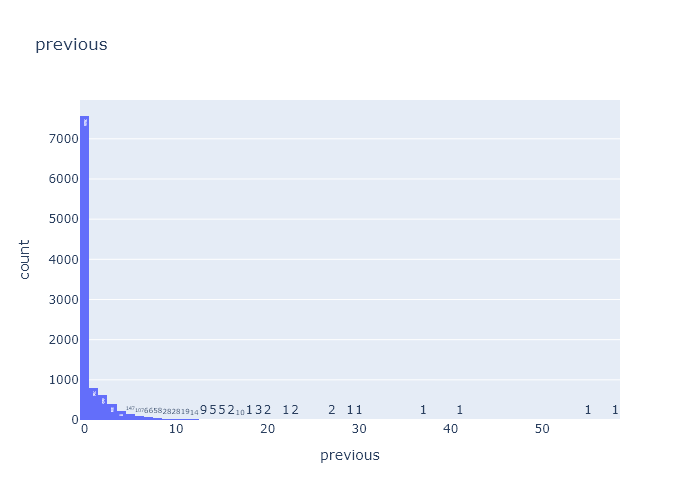

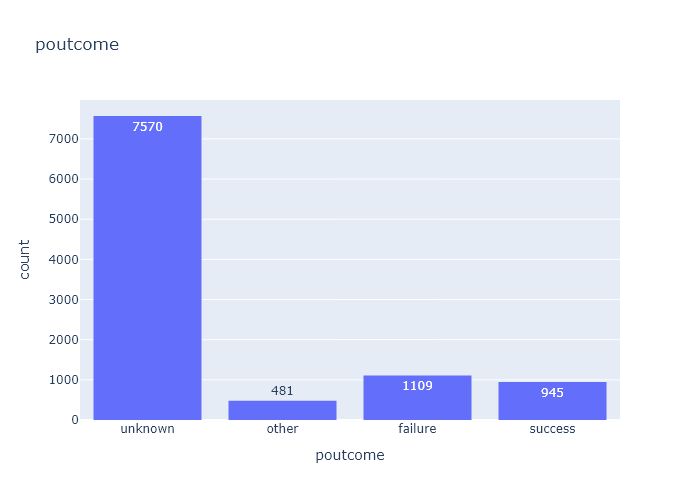

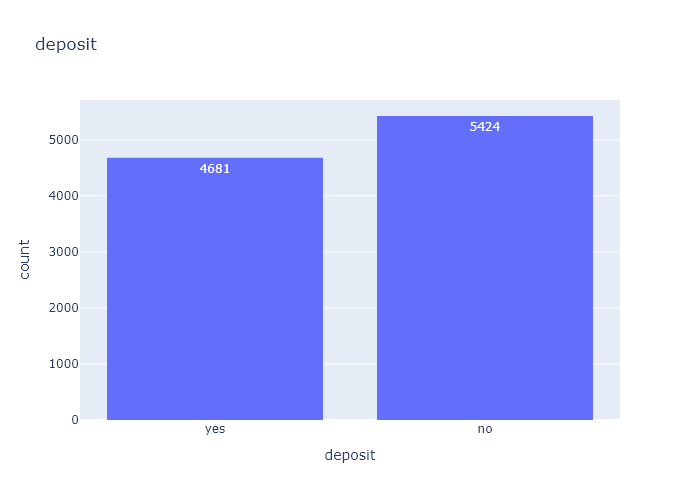

In [35]:
# визуализируем распределение признаков в наборе данных
for i in list(data.columns):
    fig = px.histogram(data, x=i, title=i, text_auto=True)
    fig.show('png')

### Выводы по графикам:  
Клиентами банка являются люди в возрасте от 18 до 95 лет, средний возраст 41 год  
Основные специальности, в которых работают клиенты банка: management, blue-collar, минимальное количество клиентов домохозяйки  
Больше половины клиентов семейные люди  
почти у всех клиентов нет просроченных кредиторов  
Чуть меньше половины клиантов не имеет кредита на жилье (housing)  
86% клиентов имеют кредит на личные нужды (loan)  
Еcть клиеныт с отрицательным балансом  
72% клиентов имели контакт на сотовый, у 21% контакт не указан  
Основной месяц, в котором был последний контакт с клиентом - май  
Средняя продолжительность контакта 368 сек  
Практически по всем клиентам нет данных по прошлой маркетинговой компании

### Визуализируем зависимости целевого признака(deposit - клиенты открывшие депозит) от количественных переменных.

In [38]:
# проведём замену значений целевого признака deposit на булевые: 1 - 'yes', 0 - 'no'
data['deposit'] = data['deposit'].apply(lambda x:int(1) if x == 'yes' else int(0))

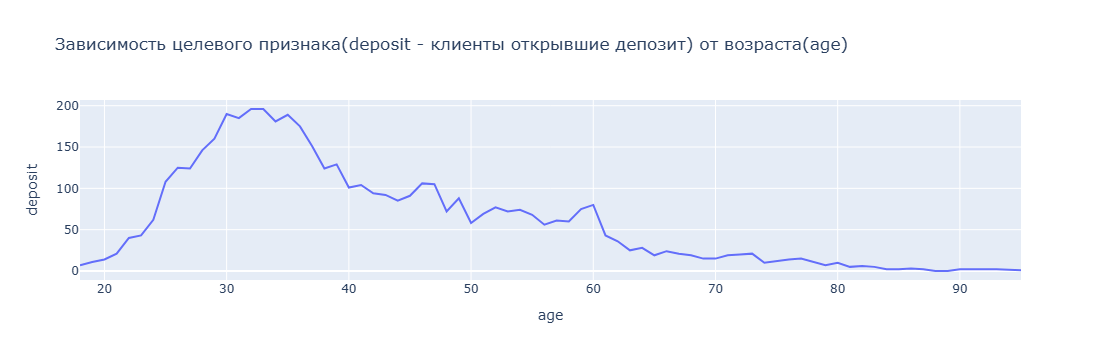

In [39]:
fig = px.line(pd.DataFrame(data.groupby('age')['deposit'].sum()).reset_index(), x='age', y='deposit', title='Зависимость целевого признака(deposit - клиенты открывшие депозит) от возраста(age)')
fig.show('png')

Из графика видно, что начиная с 18 лет открытие депозитов идет по нарастающей, максимум приходится на 31-32 года, далее количество клиентов, открывающих депозиты спадает. Но тут скорее зависимость от количества клиентов указанного возраста

### Задания 4 и 5

In [42]:
#рассчитайте описательные статистики для категориальных переменных, проинтерпретируйте результат
data.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome
count,10105,10105,10105,10105,10105,10105,10105,10105,10105
unique,11,3,3,2,2,2,3,12,4
top,management,married,secondary,no,no,no,cellular,may,unknown
freq,2315,5715,5517,9939,5243,8712,7283,2617,7570


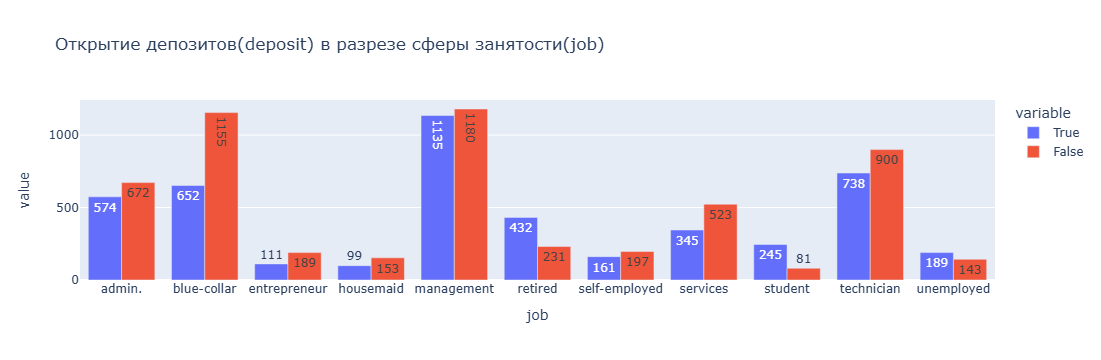

In [43]:
#постройте визуализации, иллюстрирующие результаты
fig = px.bar(data.pivot_table(
    values='education',
    index='job',    
    columns='deposit',
    aggfunc='count',
    fill_value=0
).reset_index(), x='job', y=[True,False],
             orientation='v',
             text_auto=True,
             barmode='group',
             title='Открытие депозитов(deposit) в разрезе сферы занятости(job)')
fig.show('png')

Положительно настроены на открытие депозитов группы по сфере занятости: студенты, пенсионеры  
Лояльны чуть менее 50% менеджеры и админы  
по графику наиболее лояльны к открытию депозита малочисленные группы по сфере занятости

### Задание 6

In [46]:
# Узнайте, для какого статуса предыдущей маркетинговой кампании успех в текущей превалирует над количеством неудач.
# Посмотрим, какие статусы есть у предыдущей компании
data.groupby('poutcome')['deposit'].value_counts()

poutcome  deposit
failure   0           562
          1           547
other     1           265
          0           216
success   1           861
          0            84
unknown   0          4562
          1          3008
Name: count, dtype: int64

Для группы success (успех) в текущей кампании успех преварирует над неудачами  
Но тут комментарий, что группа клиентов, участвующий в обоих кампаниях малочисленна. 

### Задание 7

In [49]:
# узнайте, в каком месяце чаще всего отказывались от предложения открыть депозит
# Для каждого месяца необходимо рассчитать отношение отказов на общее количество принятых решений в этот месяц.

percent_failure = round((data.groupby('month')['deposit'].count() - data.groupby('month')['deposit'].sum()) / data.groupby('month')['deposit'].count() * 100).sort_values(ascending=False)
print(f'В месяце {percent_failure.index[0]} больше всего отказывались от открытия депозита.')
print(percent_failure)

В месяце may больше всего отказывались от открытия депозита.
month
may    68.0
jan    61.0
jul    59.0
nov    58.0
aug    56.0
jun    55.0
feb    46.0
apr    38.0
oct    19.0
sep    17.0
dec    10.0
mar    10.0
Name: deposit, dtype: float64


### Задание 8

Нам бы очень хотелось посмотреть, люди какого возраста чаще открывают депозиты, а какого — реже. Однако, так как возрастной разброс достаточно большой, визуализация для всех возрастов или нахождение статистики для каждого возраста не будет содержательным. В аналитике принято разделять людей по возрастным подгруппам и делать выводы уже по ним.

Создайте новую переменную, в которой будет находиться индикатор принадлежности к одной из следующих категорий:  
'<30';  
'30-40';  
'40-50';  
'50-60';  
'60+'.

<Axes: xlabel='age_group', ylabel='count'>

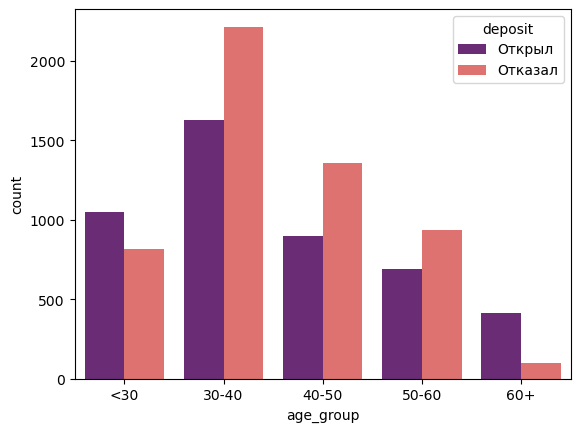

In [52]:
# создайте возрастные группы и определите, в каких группах более склонны открывать депозит, чем отказываться от предложения
# Это решение дает неправильный результат впоследствии, из-за знака меньше
#def age_group(age):
    #if age < 30:
        #age_group = '<30'
    #elif 30 <= age < 40:
        #age_group = '30-40'
    #elif 40 <= age < 50:
        #age_group = '40-50'
    #elif 50 <= age < 60:
        #age_group = '50-60'
    #else:
        #age_group = '60+'
    #return age_group
#data['age_group'] = data['age'].apply(age_group)
data['age_group'] = pd.cut(data.age, (0, 30, 40, 50, 60, 9999), labels =['<30', '30-40', '40-50', '50-60', '60+'])
label = data['deposit'].map({0: 'Отказал', 1: 'Открыл'})
sns.countplot(x='age_group', hue = label, data=data, palette = "magma")                           

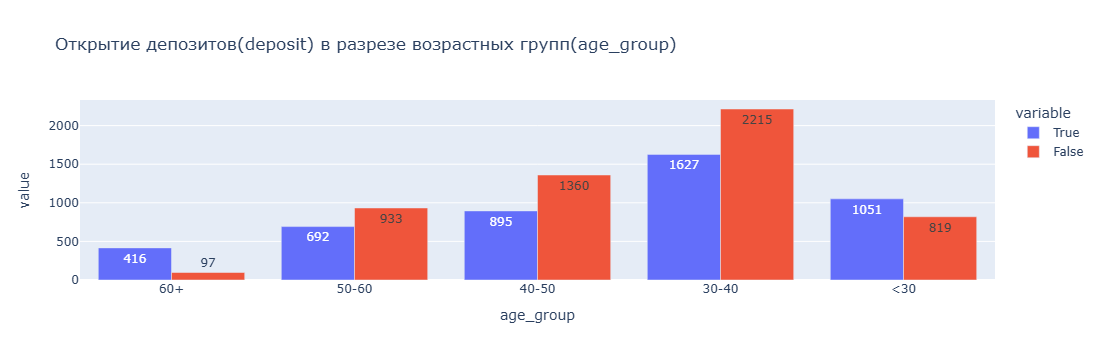

In [53]:
# После создания этой переменной постройте диаграмму (на ваш вкус), которая, с вашей точки зрения, 
# сможет наилучшим образом отобразить различия в количестве открытых/не открытых депозитов для каждой возрастной группы.

fig = px.bar(data.pivot_table(
    values='education',
    index='age_group',    
    columns='deposit',
    aggfunc='count',
    fill_value=0
).sort_index(ascending=False).reset_index(), x='age_group', y=[True,False],
             orientation='v',
             text_auto=True,
             barmode='group',
             title='Открытие депозитов(deposit) в разрезе возрастных групп(age_group)')
fig.show('png')

Две ворастные группы <30 и 60+ чаще открывают депозиты

### Задания 9 и 10

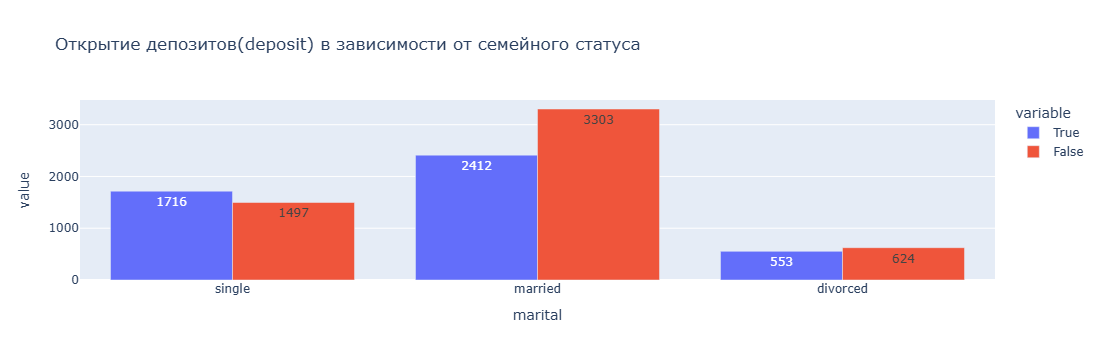

In [56]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от семейного статуса
fig = px.bar(data.pivot_table(
    values='education',
    index='marital',    
    columns='deposit',
    aggfunc='count',
    fill_value=0
).sort_index(ascending=False).reset_index(), x='marital', y=[True,False],
             orientation='v',
             text_auto=True,
             barmode='group',
             title='Открытие депозитов(deposit) в зависимости от семейного статуса')
fig.show('png')

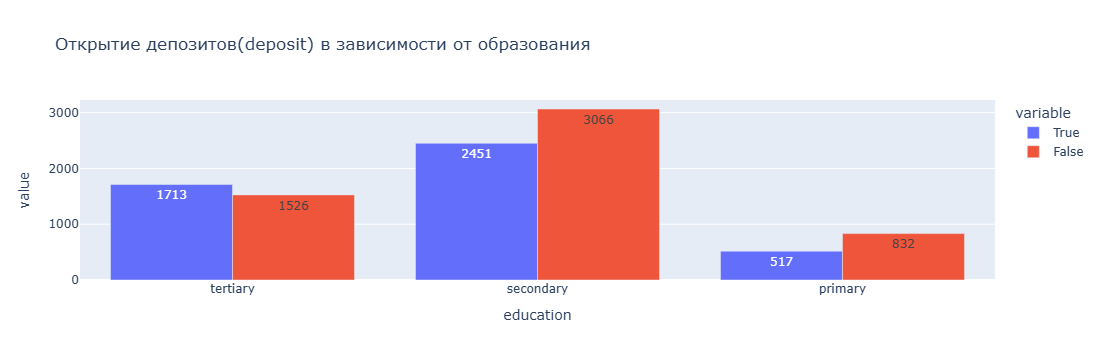

In [57]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от образования
fig = px.bar(data.pivot_table(
    values='marital',
    index='education',    
    columns='deposit',
    aggfunc='count',
    fill_value=0
).sort_index(ascending=False).reset_index(), x='education', y=[True,False],
             orientation='v',
             text_auto=True,
             barmode='group',
             title='Открытие депозитов(deposit) в зависимости от образования')
fig.show('png')

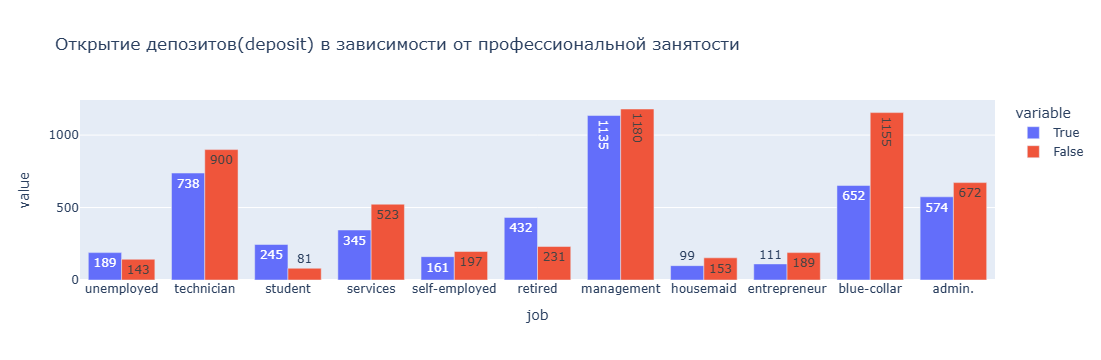

In [58]:
# постройте визуализации для открывших и неоткрывших депозит в зависимости от вида профессиональной занятости
fig = px.bar(data.pivot_table(
    values='marital',
    index='job',    
    columns='deposit',
    aggfunc='count',
    fill_value=0
).sort_index(ascending=False).reset_index(), x='job', y=[True,False],
             orientation='v',
             text_auto=True,
             barmode='group',
             title='Открытие депозитов(deposit) в зависимости от профессиональной занятости')
fig.show('png')

### Задание 11

In [60]:
# постройте сводную таблицу, чтобы определить люди с каким образованием и семейным статусом наиболее многочисленны
#(если рассматривать тех, кто открыл депозит)
pivot = data.pivot_table(
    values='age',
    index=['education', 'marital'],    
    columns='deposit',
    aggfunc='count',
    fill_value=0)[1]/data.groupby(['education', 'marital'])['deposit'].count() * 100
print(pivot)

education  marital 
primary    divorced    51.336898
           married     34.591837
           single      45.054945
secondary  divorced    43.338438
           married     41.327349
           single      50.372493
tertiary   divorced    51.632047
           married     48.514851
           single      58.709176
dtype: float64


marital,divorced,married,single
education,,,
primary,96,339,82
secondary,283,1289,879
tertiary,174,784,755


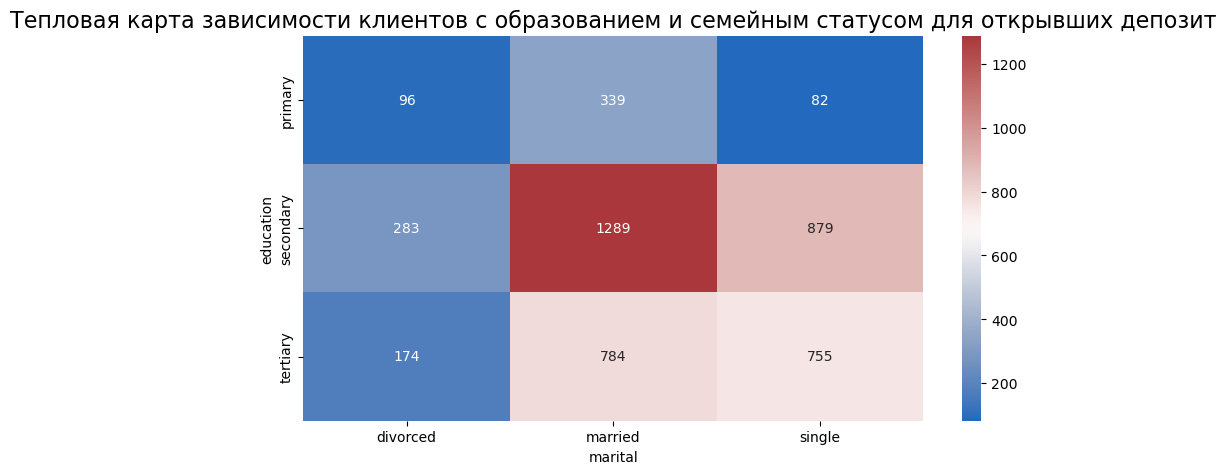

In [61]:
# построим тепловую карту для тех, кто открыл депозит
data_true = data[data['deposit']==1]

pivot_true = data_true.pivot_table(
    values='age',
    index='education',    
    columns='marital',
    aggfunc='count')

display(pivot_true)
fig = plt.figure(figsize=(10, 5))
heatmap = sns.heatmap(pivot_true, cmap='vlag', annot=True, fmt='.0f')
heatmap.set_title('Тепловая карта зависимости клиентов с образованием и семейным статусом для открывших депозит', fontsize=16);

marital,divorced,married,single
education,,,
primary,91,641,100
secondary,370,1830,866
tertiary,163,832,531


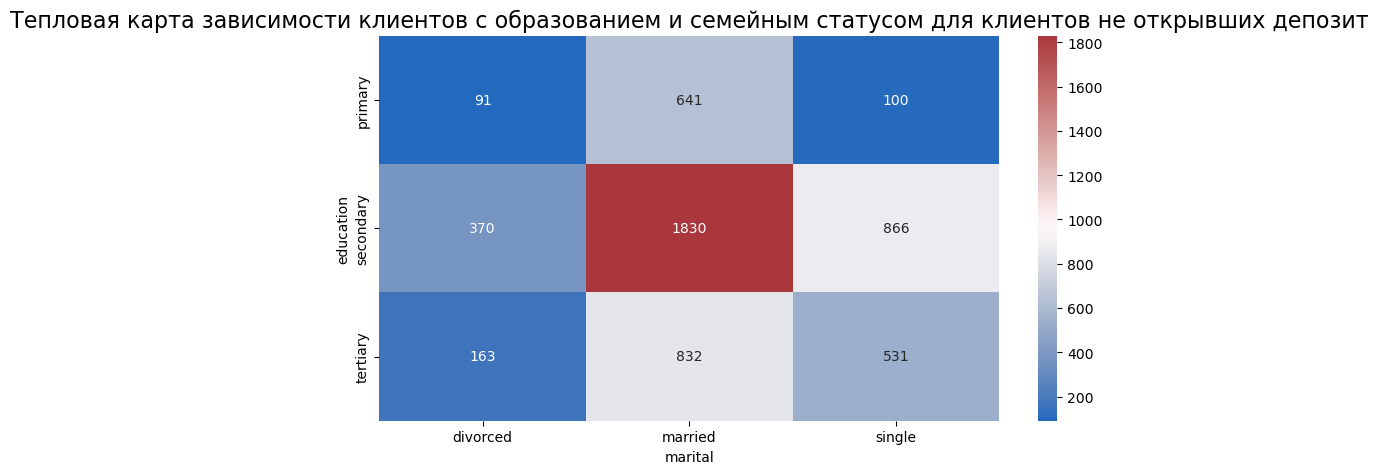

In [62]:
# построим тепловую карту для тех, кто не открыл депозит
data_false = data[data['deposit']==0]

pivot_false = data_false.pivot_table(
    values='age',
    index='education',    
    columns='marital',
    aggfunc='count')
display(pivot_false)
fig = plt.figure(figsize=(10, 5))
heatmap = sns.heatmap(pivot_false, cmap='vlag', annot=True, fmt='.0f')
heatmap.set_title('Тепловая карта зависимости клиентов с образованием и семейным статусом для клиентов не открывших депозит', fontsize=16);


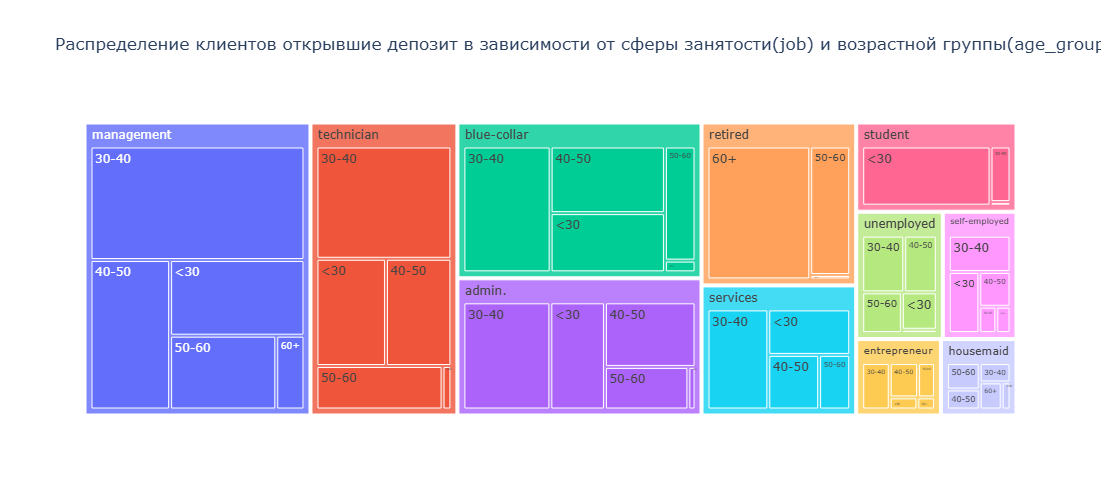

In [63]:
# построю сводную таблицу, чтобы определить люди в какой сфере занятости и возрастной группы наиболее многочисленны
#(если рассматривать тех, кто открыл депозит)
p3 = data[data['deposit']==1]
p3 = pd.DataFrame(p3.pivot_table(
    values='education',
    index=['job', 'age_group'],    
    columns='deposit',
    aggfunc='count',
    fill_value=0))

fig = px.treemap(
    data_frame=p3, #DataFrame
    path=[p3.index.get_level_values(0), p3.index.get_level_values(1)], #категориальный признак, для которого строится график
    values=1, #параметр, который сравнивается
    height=500, #высота
    width=1000, #ширина
    title='Распределение клиентов открывшие депозит в зависимости от сферы занятости(job) и возрастной группы(age_group)' #заголовок
)
#отображаем график
fig.show('png')

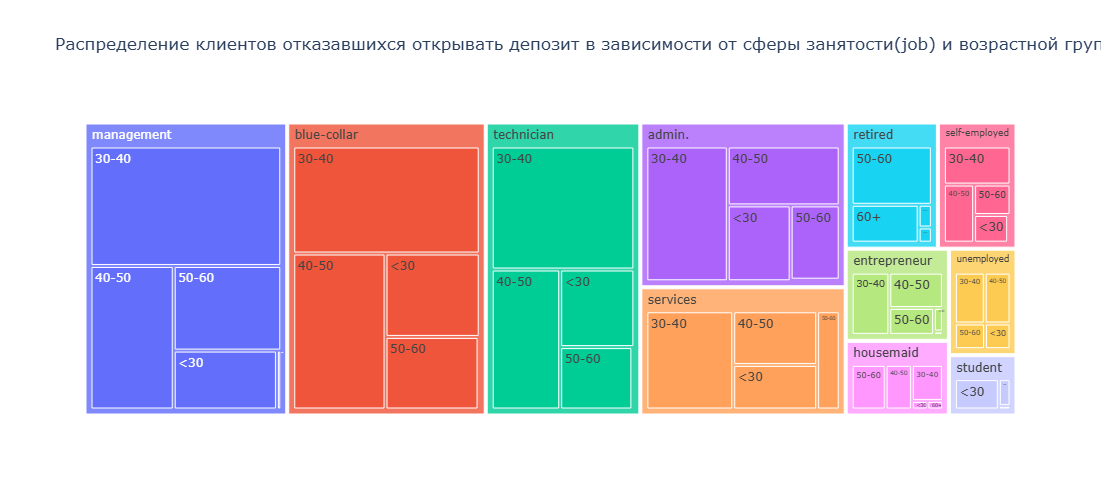

In [64]:
# построю сводную таблицу, чтобы определить люди в какой сфере занятости и возрастной группы наиболее многочисленны
#(если рассматривать тех, кто отказался открыть депозит)
p4 = data[data['deposit']==0]
p4 = pd.DataFrame(p4.pivot_table(
    values='education',
    index=['job', 'age_group'],    
    columns='deposit',
    aggfunc='count',
    fill_value=0))

fig = px.treemap(
    data_frame=p4, #DataFrame
    path=[p4.index.get_level_values(0), p4.index.get_level_values(1)], #категориальный признак, для которого строится график
    values=0, #параметр, который сравнивается
    height=500, #высота
    width=1000, #ширина
    title='Распределение клиентов отказавшихся открывать депозит в зависимости от сферы занятости(job) и возрастной группы(age_group)' #заголовок
)
#отображаем график
fig.show('png')

## Часть 3: преобразование данных

### Задание 1

In [67]:
# преобразуйте уровни образования
# Начнём с обработки категориального порядкового признака, который отвечает за уровень образования: education.
#Обработайте его с помощью метода LabelEncoder, используя метод без дополнительных настроек.
label_encoder = LabelEncoder() # кодируем порядковым кодировщиком
data_educ = label_encoder.fit_transform(data['education'])
data['education_cod'] = data_educ
print(data['education_cod'].sum())
data = data.drop(columns=['education'])

11995


In [68]:
# Ранее мы создали порядковую переменную для возраста. Обработайте её по такому же принципу, чтобы её можно было использовать при обучении модели.
data_age = label_encoder.fit_transform(data['age_group'])
data['age_group'] = data_age

In [69]:
# Обычно в задачах бинарной классификации целевую переменную кодируют как бинарный признак, который принимает значения 1 или 0. 
#Так как наш проект будет соответствовать всем правилам хорошего тона, давайте перекодируем переменную deposit таким образом, 
#чтобы вместо yes она принимала значение 1, а вместо no — 0. - перевела ранее
# Вычислите стандартное отклонение по преобразованной в корректный вид целевой переменной deposit. 
# Ответ округлите до трёх знаков после точки-разделителя.
round(data['deposit'].std(),3)

0.499

### Задания 2 и 3

In [71]:
# преобразуйте бинарные переменные в представление из нулей и единиц, у нас их 3: 'default', 'housing','loan'
# Все три мы будем модифицировать ровно так же: для слова yes мы возьмём в качестве значения 1, а для no — 0.
data['default'] = data['default'].apply(lambda x:int(1) if x == 'yes' else int(0))
data['housing'] = data['housing'].apply(lambda x:int(1) if x == 'yes' else int(0))
data['loan'] = data['loan'].apply(lambda x:int(1) if x == 'yes' else int(0))

In [72]:
#Вычислите среднее арифметическое для каждой из получившихся переменных, сложите три результата и в качестве ответа впишите итог,
#округлив его до трёх знаков после точки-разделителя
mean_bynnary = data['default'].mean() + data['housing'].mean() + data['loan'].mean()
print(round(mean_bynnary, 3))

0.635


### Задание 4

In [74]:
# создайте дамми-переменные для 'job', 'marital', 'contact', 'month', 'poutcome'.
data = pd.get_dummies(data, columns=['job', 'marital', 'contact', 'month', 'poutcome'], 
                      prefix=['job', 'marital', 'contact', 'month', 'poutcome'],
                      drop_first=False,
                      dtype=int)
data.shape

(10105, 46)

In [75]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 10105 entries, 0 to 11161
Data columns (total 46 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                10105 non-null  int64  
 1   default            10105 non-null  int64  
 2   balance            10105 non-null  float64
 3   housing            10105 non-null  int64  
 4   loan               10105 non-null  int64  
 5   day                10105 non-null  int64  
 6   duration           10105 non-null  int64  
 7   campaign           10105 non-null  int64  
 8   pdays              10105 non-null  int64  
 9   previous           10105 non-null  int64  
 10  deposit            10105 non-null  int64  
 11  age_group          10105 non-null  int32  
 12  education_cod      10105 non-null  int32  
 13  job_admin.         10105 non-null  int32  
 14  job_blue-collar    10105 non-null  int32  
 15  job_entrepreneur   10105 non-null  int32  
 16  job_housemaid      10105 no

### Задания 5 и 6

<Axes: >

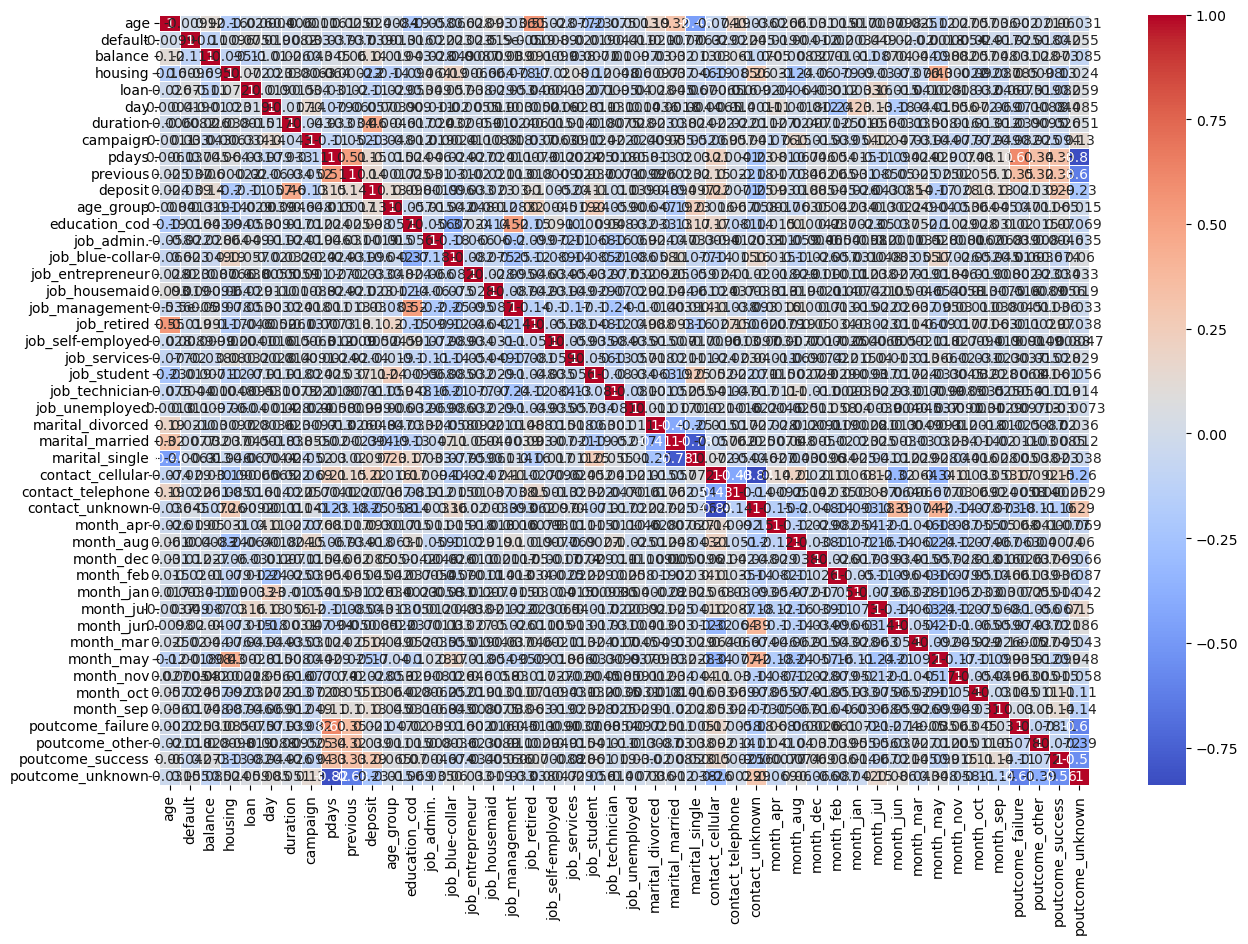

In [77]:
# постройте корреляционную матрицу и оцените данные на предмет наличия мультиколлинеарности
corr_matrix = data.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(15,10))
sns.heatmap(data.corr(numeric_only = True), annot=True, linewidths=.5, ax=ax, cmap='coolwarm')

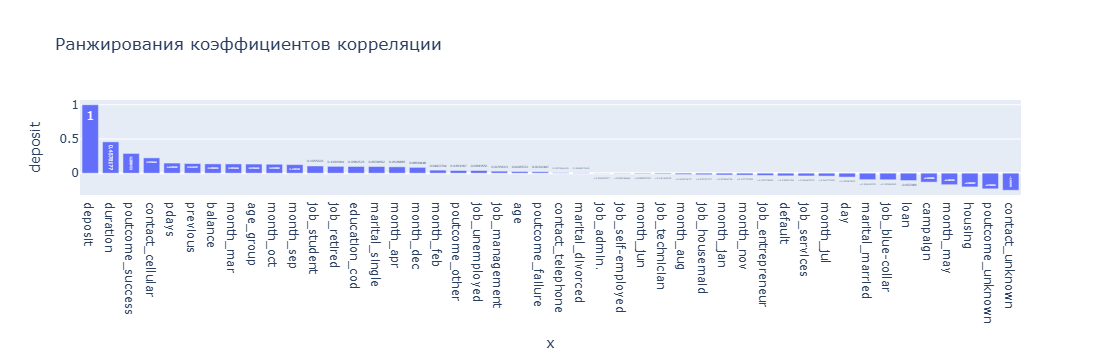

In [78]:
corrs = corr_matrix.drop('deposit', axis=0)

fig = px.bar(corr_matrix['deposit'].sort_values(ascending=False),
             x=list(corr_matrix['deposit'].sort_values(ascending=False).index),
             y='deposit',
             text_auto=True,
             title='Ранжирования коэффициентов корреляции'
             )
fig.show('png')  

Мультиколлинеарность признаков отсутсвует.

Признаки наиболее коррелирующие с целевой переменной:

продолжительность контакта в секундах(duration)  
успех результата прошлой маркетинговой кампании(poutcome_success)  
контакт с клиентом по сотовому(contact_cellular)

### Задания 7 и 8

Теперь вам необходимо определить целевую переменную и предикторы, а также разделить выборку на обучающую и тестовую.

При разбиении задайте параметр random_state = 42, а размер тестовой выборки возьмите за 0.33. Не забудьте добавить аргумент, определяющий сохранение соотношений целевого признака.

In [82]:
X = data.drop(['deposit'], axis=1)
y = data['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

In [83]:
# рассчитайте необходимые показатели
#Проверим размеры полученных выборок:

print('Размер тестовой выборки: {}'.format(X_test.shape))


Размер тестовой выборки: (3335, 45)


In [84]:
# Каково среднее значение целевой переменной на тестовой выборке? Ответ округлите до двух знаков после точки-разделителя.
print(round(y_test.mean(),2))

0.46


### Задание 9

In [86]:
# с помощью SelectKBest отберите 15 наиболее подходящих признаков
selector = SelectKBest(f_classif, k=15)
selector.fit(X_train, y_train)
selector.get_feature_names_out()
selector_col = list(selector.get_feature_names_out())
selector_col

['balance',
 'housing',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'age_group',
 'contact_cellular',
 'contact_unknown',
 'month_mar',
 'month_may',
 'month_oct',
 'month_sep',
 'poutcome_success',
 'poutcome_unknown']

In [87]:
# оставим только выбранные признаки
data_best = data[['balance',
 'housing',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'age_group',
 'contact_cellular',
 'contact_unknown',
 'month_mar',
 'month_may',
 'month_oct',
 'month_sep',
 'poutcome_success',
 'poutcome_unknown', 'deposit']]

In [88]:
# Разобью на тестовую и обучающую выборку
X = data_best.drop(['deposit'], axis=1)
y = data_best['deposit']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.33)

### Задание 10

In [90]:
# нормализуйте данные с помощью minmaxsxaler
# Помните, что нормализация требуется для предикторов, а не для целевой переменной.
# Нормализуйте предикторы в обучающей и тестовой выборках.
from sklearn.preprocessing import MinMaxScaler
scaler = preprocessing.MinMaxScaler()
scaler.fit(X_train)
X_train_scal = scaler.transform(X_train)
#X_train_scal = pd.DataFrame(X_train_scal, columns=X_train.columns)
X_test_scal = scaler.transform(X_test)
#X_test_scal = pd.DataFrame(X_test_scal, columns=X_test.columns)

In [91]:
# Рассчитайте среднее арифметическое для первого предиктора (т. е. для первого столбца матрицы) из тестовой выборки. 
# Ответ округлите до двух знаков после точки-разделителя.
print(round(X_test_scal[:,0].mean(),2))
print(X_test_scal.shape)
print(X_train_scal.shape)

0.47
(3335, 15)
(6770, 15)


# Часть 4: Решение задачи классификации: логистическая регрессия и решающие деревья

### Задание 1

In [94]:
# обучите логистическую регрессию и рассчитайте метрики качества
# Для получившейся модели вычислите значение accuracy на тестовой выборке. Ответ округлите до двух знаков после точки-разделителя.

#Создаём объект класса LogisticRegression
log_reg = linear_model.LogisticRegression(random_state=42, solver='sag', max_iter=1000)
#Обучаем модель
log_reg.fit(X_train_scal, y_train)
y_train_pred = log_reg.predict(X_train_scal)
y_test_pred = log_reg.predict(X_test_scal)
#Выводим результирующие коэффициенты
print('Accuracy train: {:.2f}'.format(metrics.accuracy_score(y_train, y_train_pred)))
print('Accuracy test: {:.2f}'.format(metrics.accuracy_score(y_test, y_test_pred)))
print('F1 test: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))

Accuracy train: 0.82
Accuracy test: 0.81
F1 test: 0.78


### Задания 2,3,4

In [96]:
# обучите решающие деревья, настройте максимальную глубину
# В качестве параметров для начала возьмём следующие: criterion = 'entropy'; random_state = 42. Остальные параметры оставьте по умолчанию.
#Создаём модель
model = tree.DecisionTreeClassifier(
    criterion='entropy', #критерий информативности
    random_state=42 #генератор случайных чисел  
)
#Обучаем модель на тренировочной выборке
model.fit(X_train_scal, y_train)
#Делаем предсказание для каждой из выборок
y_train_pred = model.predict(X_train_scal)
print('Train hold-out accuracy: {:.2f}'.format(metrics.accuracy_score(y_train, y_train_pred)))
print(model.tree_.max_depth)

Train hold-out accuracy: 1.00
32


In [97]:
# Переберите различные максимальные глубины деревьев и найдите глубину дерева, для которой будет максимальное значение метрики accuracy, 

tree_model = tree.DecisionTreeClassifier(
    criterion='entropy', #критерий информативности
    max_depth=6, #максимальная глубина
    random_state=42 #генератор случайных чисел  
)
#Обучаем модель на тренировочной выборке
tree_model.fit(X_train_scal, y_train)
#Делаем предсказание для каждой из выборок
y_test_pred = model.predict(X_test_scal)
y_train_pred = model.predict(X_train_scal)
print('Train hold-out accuracy: {:.2f}'.format(metrics.accuracy_score(y_train, y_train_pred)))
print('Test hold-out accuracy: {:.2f}'.format(metrics.accuracy_score(y_test, y_test_pred)))
print('Test hold-out F1: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print(model.tree_.max_depth)

Train hold-out accuracy: 1.00
Test hold-out accuracy: 0.75
Test hold-out F1: 0.73
32


In [98]:
# подберите оптимальные параметры с помощью gridsearch, , перебрав следующие параметры: 'min_samples_split': [2, 5, 7, 10];
# 'max_depth':[3,5,7]

from sklearn.model_selection import GridSearchCV
# задаём сетку параметров
param_grid = [
              {'min_samples_split': [2, 5, 7, 10] , # Минимальное количество выборок, необходимое для разделения внутреннего узла
              'max_depth':[3,5,7] # Максимальная глубина дерева
               }              
]

grid_search = GridSearchCV(
    estimator=tree.DecisionTreeClassifier(criterion='entropy',
        
        random_state=42, #генератор случайных чисел
        ), 
    param_grid=param_grid, 
    cv = 3,
    scoring='f1'
)  

grid_search.fit(X_train_scal, y_train) 

y_train_pred = grid_search.predict(X_train_scal)
y_test_pred = grid_search.predict(X_test_scal)

print("accuracy на тестовом наборе: {:.2f}".format(grid_search.score(X_test_scal, y_test)))
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print("Наилучшие значения гиперпараметров: {}".format(grid_search.best_params_))

accuracy на тестовом наборе: 0.80
f1_score на тестовом наборе: 0.80
Наилучшие значения гиперпараметров: {'max_depth': 7, 'min_samples_split': 7}


# Часть 5: Решение задачи классификации: ансамбли моделей и построение прогноза

### Задание 1

In [101]:
# обучите на ваших данных случайный лес n_estimators = 100; criterion = 'gini'; min_samples_leaf = 5; max_depth = 10; random_state = 42
#Создаем объект класса случайный лес
rf = ensemble.RandomForestClassifier(n_estimators = 100, criterion = 'gini', min_samples_leaf = 5, max_depth = 10, random_state=42)

#Обучаем модель
rf.fit(X_train_scal, y_train)
#Выводим значения метрики 
y_train_pred = rf.predict(X_train_scal)

y_test_pred = rf.predict(X_test_scal)
print('recall  на тестовом наборе: {:.2f}'.format(metrics.recall_score(y_test, y_test_pred)))
print('Accuracy  на тестовом наборе: {:.2f}'.format(metrics.accuracy_score(y_test, y_test_pred)))
print('F1  на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print(f'Мерики на тестовых даннных\n {metrics.classification_report(y_test, y_test_pred)}')
print(f'Мерики на тренировочных данных\n {metrics.classification_report(y_train, y_train_pred)}')

recall  на тестовом наборе: 0.83
Accuracy  на тестовом наборе: 0.83
F1  на тестовом наборе: 0.82
Мерики на тестовых даннных
               precision    recall  f1-score   support

           0       0.85      0.82      0.84      1790
           1       0.80      0.83      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335

Мерики на тренировочных данных
               precision    recall  f1-score   support

           0       0.88      0.86      0.87      3634
           1       0.84      0.86      0.85      3136

    accuracy                           0.86      6770
   macro avg       0.86      0.86      0.86      6770
weighted avg       0.86      0.86      0.86      6770



### Задания 2 и 3

In [103]:
# используйте для классификации градиентный бустинг и сравните качество со случайным лесом
# Используйте градиентный бустинг для решения задачи классификации, задав для него следующие параметры:
# learning_rate = 0.05; n_estimators = 300; min_samples_leaf = 5; max_depth = 5; random_state = 42
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(
    n_estimators=300,
    random_state=42,
    min_samples_leaf=5,
    learning_rate=0.05,
    max_depth=5         
)

gb.fit(X_train_scal, y_train)
y_train_pred = gb.predict(X_train_scal)
y_test_pred = gb.predict(X_test_scal)
print(f'Мерики на тестовых даннных\n {metrics.classification_report(y_test, y_test_pred)}')
print(f'Мерики на тренировочных данных\n {metrics.classification_report(y_train, y_train_pred)}')

print('Accuracy  на тестовом наборе: {:.2f}'.format(metrics.accuracy_score(y_test, y_test_pred)))
print('F1  на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))

Мерики на тестовых даннных
               precision    recall  f1-score   support

           0       0.85      0.82      0.84      1790
           1       0.80      0.83      0.82      1545

    accuracy                           0.83      3335
   macro avg       0.83      0.83      0.83      3335
weighted avg       0.83      0.83      0.83      3335

Мерики на тренировочных данных
               precision    recall  f1-score   support

           0       0.90      0.89      0.89      3634
           1       0.87      0.89      0.88      3136

    accuracy                           0.89      6770
   macro avg       0.89      0.89      0.89      6770
weighted avg       0.89      0.89      0.89      6770

Accuracy  на тестовом наборе: 0.83
F1  на тестовом наборе: 0.82


### Задание 4

In [105]:
# объедините уже известные вам алгоритмы с помощью стекинга 
# В этом задании вам необходимо использовать стекинг, объединив те алгоритмы, которые вы уже использовали ранее: 
# решающие деревья, логистическую регрессию и градиентный бустинг. В качестве метамодели используйте модель логистической регрессии.
# Параметры оставьте те же, что были в ваших алгоритмах в предыдущих заданиях.
from sklearn.ensemble import StackingClassifier
#Создаем список кортежей вида: (наименование модели, модель)
estimators = [
    ('lr', log_reg),
    ('dt',  tree_model),
    ('rf', rf),
    ('gb', gb)   
]

#Создаем объект класса стекинг
steg_model = StackingClassifier(
    estimators=estimators,
    final_estimator=gb)
    

steg_model.fit(X_train_scal, y_train)
y_train_pred = steg_model.predict(X_train_scal)
y_test_pred = steg_model.predict(X_test_scal)
print(f'precision на тестовых даннных\n {metrics.precision_score(y_test, y_test_pred)}')
print(f'Мерики на тестовых даннных\n {metrics.classification_report(y_test, y_test_pred)}')
print(f'Мерики на тренировочных данных\n {metrics.classification_report(y_train, y_train_pred)}')
print('Accuracy  на тестовом наборе: {:.2f}'.format(metrics.accuracy_score(y_test, y_test_pred)))
print('F1  на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))

precision на тестовых даннных
 0.794099569760295
Мерики на тестовых даннных
               precision    recall  f1-score   support

           0       0.85      0.81      0.83      1790
           1       0.79      0.84      0.81      1545

    accuracy                           0.82      3335
   macro avg       0.82      0.82      0.82      3335
weighted avg       0.83      0.82      0.82      3335

Мерики на тренировочных данных
               precision    recall  f1-score   support

           0       0.89      0.85      0.87      3634
           1       0.84      0.87      0.86      3136

    accuracy                           0.86      6770
   macro avg       0.86      0.86      0.86      6770
weighted avg       0.86      0.86      0.86      6770

Accuracy  на тестовом наборе: 0.82
F1  на тестовом наборе: 0.81


### Задание 5

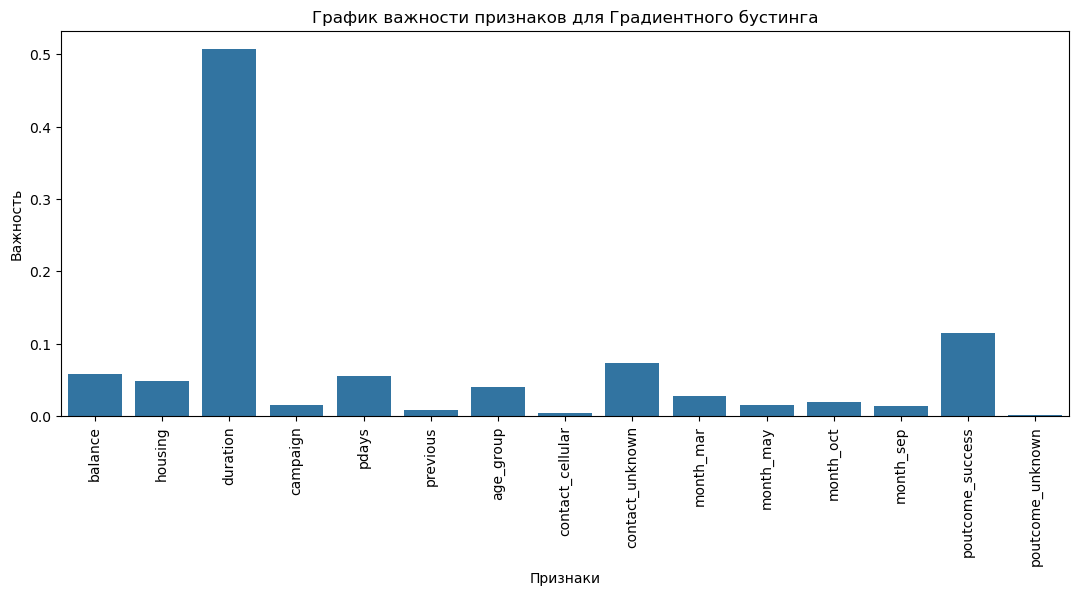

In [107]:
fig, ax = plt.subplots(figsize=(13, 5)) #фигура + координатная плоскость
feature = X.columns #признаки
feature_importances = gb.feature_importances_ #важность признаков
#Строим столбчатую диаграмму
sns.barplot(x=feature, y=feature_importances, ax=ax);
#Добавляем подпись графику, осям абцисс и ординат
plt.xticks(rotation=90)
ax.set_title('График важности признаков для Градиентного бустинга')
ax.set_xlabel('Признаки')
ax.set_ylabel('Важность');

### Задания 6,7,8

In [109]:
# реализуйте оптимизацию гиперпараметров с помощью Optuna
# Один из более продвинутых вариантов оптимизации гиперпараметров — фреймворк Optuna. 
# Примените его для оптимизации гиперпараметров. Для перебора возьмите случайный лес и следующие параметры:
# n_estimators = trial.suggest_int('n_estimators', 100, 200, 1); 
# max_depth = trial.suggest_int('max_depth', 10, 30, 1);
# min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1).

import optuna
def optuna_rf(trial):
  # задаем пространства поиска гиперпараметров
  n_estimators = trial.suggest_int('n_estimators', 100, 200, 1)
  max_depth = trial.suggest_int('max_depth', 10, 30, 1)
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 10, 1)

  # создаем модель
  model = rf
  # обучаем модель
  model.fit(X_train_scal, y_train)
  score = metrics.f1_score(y_train, model.predict(X_train_scal))

  return score

In [110]:
%%time
# cоздаем объект исследования
# можем напрямую указать, что нам необходимо максимизировать метрику direction="maximize"
study = optuna.create_study(study_name="RandomForestClassifier", direction="maximize")
# ищем лучшую комбинацию гиперпараметров n_trials раз
study.optimize(optuna_rf, n_trials=50)

[I 2025-04-14 23:06:01,916] A new study created in memory with name: RandomForestClassifier
[I 2025-04-14 23:06:02,261] Trial 0 finished with value: 0.8478740157480315 and parameters: {'n_estimators': 193, 'max_depth': 29, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.8478740157480315.
[I 2025-04-14 23:06:02,598] Trial 1 finished with value: 0.8478740157480315 and parameters: {'n_estimators': 176, 'max_depth': 22, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.8478740157480315.
[I 2025-04-14 23:06:02,943] Trial 2 finished with value: 0.8478740157480315 and parameters: {'n_estimators': 176, 'max_depth': 28, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.8478740157480315.
[I 2025-04-14 23:06:03,297] Trial 3 finished with value: 0.8478740157480315 and parameters: {'n_estimators': 146, 'max_depth': 13, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.8478740157480315.
[I 2025-04-14 23:06:03,646] Trial 4 finished with value: 0.8478740157480315 and parameters: {'n_

CPU times: total: 17.6 s
Wall time: 17.7 s


In [111]:
# рассчитаем точность для тестовой выборки
model = ensemble.RandomForestClassifier(**study.best_params,random_state=42)
model.fit(X_train_scal, y_train)
y_test_pred = model.predict(X_test_scal)

score = metrics.f1_score(y_test, y_test_pred)
print(f'Наилучшие значения гиперпараметров {study.best_params}')
print(f'F1 for test data={score:.2f}')
print(f'Accuracy for test data={metrics.accuracy_score(y_test, y_test_pred):.2f}')

Наилучшие значения гиперпараметров {'n_estimators': 193, 'max_depth': 29, 'min_samples_leaf': 4}
F1 for test data=0.82
Accuracy for test data=0.83


### Выводы  
Приведу в стаблице свод по методам и метрикам  

|  Метод/Метрика       |  F1  | Accuracy |  
|----------------------|------|----------|  
| LogisticRegression   | 0.78 |  0.81    |  
|DecisionTreeClassifier| 0.73 |  0.75    |  
|RandomForestClassifier| 0.82 |  0.83    |  
|GradientBoostingClass | 0.82 |  0.83    |  
|StackingClassifier    | 0.81 |  0.82    |  
|RandomForest/Optuna   | 0.82 |  0.83    |

Лучшие результаты у модели Случайного леса, Градиентого бустинга и Случайного леса с подобранными гиперпараметрами методом Optuna.  

В ходе исследования выделены 3 наиболее важных признака:  
* duration (продолжительность контакта в секундах)
* poutcome_success(результат прошлой маркетинговой кампании - success(успех, согласие))
* contact_unknown(тип контакта с клиентом- unknown(неизвестный))

Основными прризнаками являются те показателя, которые зависят от сотрудников банка: насколько сотрудник умеет за короткое время донести информацию до клиента.  

Также стоит упомянуть о лояльности клиентах - как показали исследования клиентов ранее открывшие депозиты в прошлые маркетиновые кампании охотно соглашаются и в новой кампании - данную группу необходимо использовать в новых маркетинговых кампаниях и сохранять их лояльность. При планировании новой маркетинговой кампании необходимо обязательно более тщательно подходить к вопросу выбора контакта с клиентом - в данной кампании порядка 21% вид контакта неизвестен, данный факт касается также и poutcome(результат прошлой маркетинговой кампании).4	0.85
